In [419]:
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import obspy


from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    find_paths,
    find_date_in_strings,
)
from seismicif.metrics import iou
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from dynamicTreeCut import cutreeHybrid
from scipy.spatial.distance import pdist
from datetime import timedelta
from seismicif.datamod.preproc_utils import preproc_stream


def print_cluster_info(clusters, labels):
    for i in np.unique(clusters):
        cluster_labs = labels[clusters == i]
        cluster_labs_non_none = [x for x in cluster_labs if x is not None]

        if cluster_labs_non_none:
            print(f"Cluster {i}:")
            print(cluster_labs_non_none)
            print(np.sum(clusters == i))


def cluster_info(cluster):
    size = len(cluster)

    mapping = {"CAL": "MM", "ID": "MM", "TEQ": "EQ", "REQ": "EQ"}

    cluster["label"] = cluster["label"].replace(mapping)

    return cluster["label"].value_counts(dropna=False) / size

In [420]:
station = "KARAT"
network = "DK"
karat_paths = paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)

catalog = pd.read_csv("../catalogs/DK/KARAT.csv")
catalog = preproc_flow_annotations(catalog)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

dtw_path = f"../output/{network}/dtw/distances"

with open(f"{dtw_path}/{station}.pkl", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

In [421]:
labs = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[0]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)

In [422]:
Xa = X.copy()
for i in range(Xa.shape[1]):
    x = np.delete(Xa[:, i], i)
    Xa[i, i] = np.min(x)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens)
# lens = (lens == 1800).astype(float).reshape(-1, 1)
lens = lens.reshape(-1, 1)

Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.hstack([Xa, np.isnan(Xa[:, -1]).astype(float).reshape(-1, 1)])
Xa = np.nan_to_num(Xa, nan=0.5)
a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

In [423]:
Z = linkage(Xa, method="ward")
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]
segments["cluster"] = clusters
segments["label"] = labs
segments.to_csv(f"../output/{network}/if/segments/{station}.csv")

..cutHeight not given, setting it to 30.106001162630267  ===>  99% of the (truncated) height range in dendro.
..done.


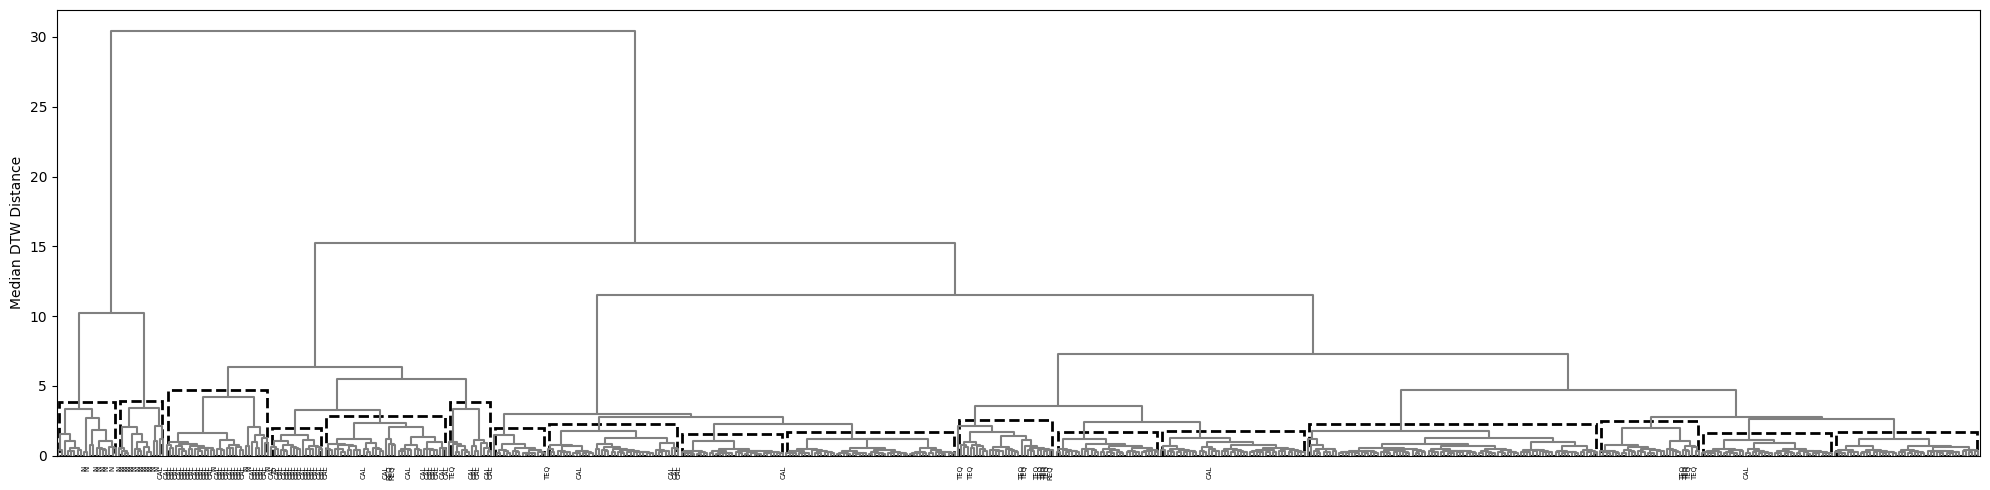

In [424]:
plt.figure(figsize=(20, 5))
# --- dendrogram ---
ddata = dendrogram(Z, labels=labs, link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 8  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()

In [425]:
clusters.max()

17

In [426]:
info = {}
for cl in np.unique(clusters):
    cluster = segments[clusters == cl].copy().reset_index(drop=True)
    info[cl] = cluster_info(cluster)


df = pd.DataFrame(info).T
df.fillna(0, inplace=True)
df

label,EQ,MM,N,None
1,0.000000,0.000000,0.000000,1.000000
2,0.000000,0.000000,0.000000,1.000000
3,0.000000,0.000000,0.000000,1.000000
4,0.000000,0.021739,0.000000,0.978261
5,0.023810,0.095238,0.000000,0.880952
6,0.000000,0.023810,0.000000,0.976190
7,0.051282,0.282051,0.000000,0.666667
8,0.000000,0.030303,0.000000,0.969697
9,0.000000,0.000000,0.000000,1.000000
10,0.000000,0.878788,0.121212,0.000000


In [430]:
cl = 7
cluster = segments[clusters == cl].copy().reset_index(drop=True)
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2023-07-27T06:56:40.000000Z,2023-07-27T07:06:40.000000Z,2023-07-27T07:00:00.000000Z,0.720379,0.711134,7,CAL
1,2023-03-21T06:57:30.000000Z,2023-03-21T07:00:50.000000Z,2023-03-21T06:58:20.000000Z,0.686925,0.731895,7,REQ
2,2023-04-19T01:34:02.320000Z,2023-04-19T01:38:12.320000Z,2023-04-19T01:34:52.320000Z,0.685737,0.708858,7,REQ
3,2022-12-26T12:00:00.000000Z,2022-12-26T12:03:20.000000Z,2022-12-26T12:00:00.000000Z,0.678049,0.492322,7,CAL
4,2023-07-07T21:15:42.320000Z,2023-07-07T21:20:42.320000Z,2023-07-07T21:16:32.320000Z,0.669330,0.475412,7,CAL
5,2023-05-09T21:44:52.320000Z,2023-05-09T21:48:12.320000Z,2023-05-09T21:45:42.320000Z,0.660905,0.423029,7,CAL
6,2022-11-01T04:47:30.000000Z,2022-11-01T04:51:40.000000Z,2022-11-01T04:48:20.000000Z,0.656864,0.444603,7,None
7,2023-09-09T19:50:50.000000Z,2023-09-09T19:55:50.000000Z,2023-09-09T19:51:40.000000Z,0.656815,0.415744,7,CAL
8,2022-10-04T06:55:14.395000Z,2022-10-04T06:57:44.395000Z,2022-10-04T06:55:14.395000Z,0.649506,0.401356,7,CAL
9,2022-12-27T04:05:50.000000Z,2022-12-27T04:11:40.000000Z,2022-12-27T04:08:20.000000Z,0.649249,0.550275,7,None


### New KARAT

In [388]:
station = "KARAT"
network = "DK"
karat_paths = paths = find_paths("DK", "KARAT", "HHZ.D", start=2022, stop=2023)

catalog = pd.read_csv("../catalogs/DK/KARAT.csv")
catalog = preproc_flow_annotations(catalog)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

dtw_path = f"../output/{network}/dtw/distances"

with open(f"{dtw_path}/{station}.pkl", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

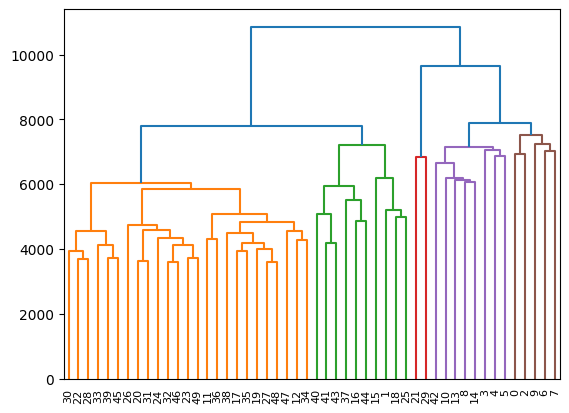

..cutHeight not given, setting it to 10776.245993136581  ===>  99% of the (truncated) height range in dendro.
..done.


In [389]:
D = np.zeros([50, 50])
for i in range(50):
    for j in range(i + 1, 50):
        D[i, j] = np.median(results[i][j][0])
        D[j, i] = D[i, j]

D = squareform(D)
Z = linkage(D, method="complete")
dendrogram(Z)
plt.show()

clusters = cutreeHybrid(Z, D, minClusterSize=1, deepSplit=3)

In [390]:
top_segments = segments.copy().iloc[:50, :]

ref_templates = []
for cl in np.unique(clusters["labels"]):
    ref_templates.append(top_segments[clusters["labels"] == cl].index[0])

ref_templ_idx = np.sort(np.array(ref_templates))
# ref_templ_idx = np.arange(50)
segments = segments.drop(index=ref_templ_idx).reset_index(drop=True)

X = X[:, ref_templ_idx]
X = np.delete(X, ref_templ_idx, axis=0)

In [391]:
labs = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[0]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)

In [392]:
Xa = X.copy()
for i in range(Xa.shape[1]):
    x = np.delete(Xa[:, i], i)
    Xa[i, i] = np.min(x)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens)
# lens = (lens == 1800).astype(float).reshape(-1, 1)
lens = lens.reshape(-1, 1)

Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.hstack([Xa, np.isnan(Xa[:, -1]).astype(float).reshape(-1, 1)])
Xa = np.nan_to_num(Xa, nan=0.5)
a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

In [393]:
Z = linkage(Xa, method="ward")
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]
segments["cluster"] = clusters
segments["label"] = labs

..cutHeight not given, setting it to 14.926794521507775  ===>  99% of the (truncated) height range in dendro.
..done.


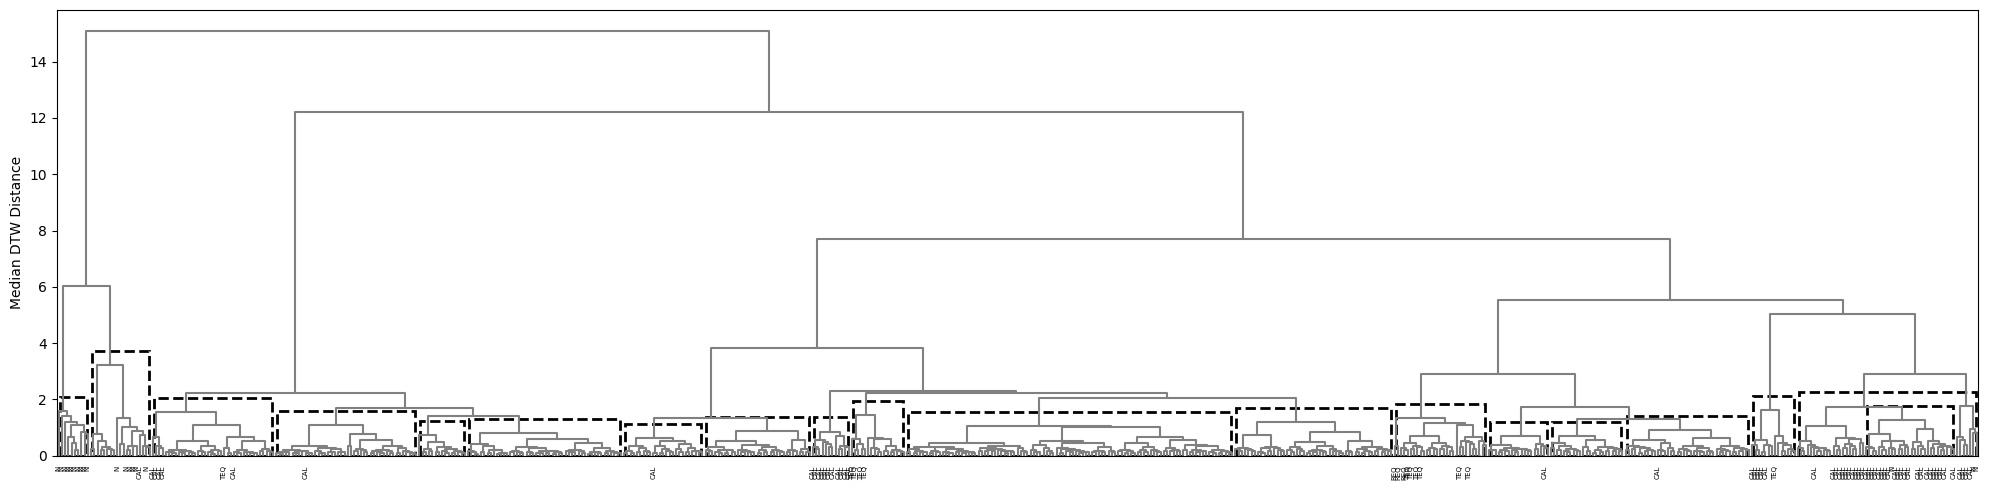

In [394]:
plt.figure(figsize=(20, 5))
# --- dendrogram ---
ddata = dendrogram(Z, labels=labs, link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 8  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()

In [395]:
info = {}
for cl in np.unique(clusters):
    cluster = segments[clusters == cl].copy().reset_index(drop=True)
    info[cl] = cluster_info(cluster)


df = pd.DataFrame(info).T
df.fillna(0, inplace=True)
df

label,EQ,MM,N,None
1,0.000000,0.000000,0.000000,1.000000
2,0.000000,0.000000,0.000000,1.000000
3,0.000000,0.000000,0.000000,1.000000
4,0.000000,0.022727,0.000000,0.977273
5,0.000000,0.025641,0.000000,0.974359
6,0.026316,0.131579,0.000000,0.842105
7,0.000000,0.000000,0.000000,1.000000
8,0.310345,0.000000,0.000000,0.689655
9,0.000000,0.535714,0.071429,0.392857
10,0.000000,0.785714,0.035714,0.178571


In [403]:
cl = 6
cluster = segments[clusters == cl].copy().reset_index(drop=True)
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2022-12-27T02:52:30.000000Z,2022-12-27T03:35:00.000000Z,2022-12-27T03:01:40.000000Z,0.715773,0.554152,6,CAL
1,2022-10-17T09:09:55.350000Z,2022-10-17T12:50:45.350000Z,2022-10-17T09:29:55.350000Z,0.703665,0.516989,6,CAL
2,2023-10-02T14:13:29.415000Z,2023-10-02T15:45:59.415000Z,2023-10-02T15:01:49.415000Z,0.701096,0.454392,6,CAL
3,2023-09-16T12:27:39.390000Z,2023-09-16T12:49:19.390000Z,2023-09-16T12:29:19.390000Z,0.698963,0.610813,6,CAL
4,2023-10-16T09:47:30.000000Z,2023-10-16T15:35:50.000000Z,2023-10-16T11:44:10.000000Z,0.675883,0.681411,6,TEQ
5,2022-12-02T10:32:29.350000Z,2022-12-02T19:21:39.350000Z,2022-12-02T18:47:29.350000Z,0.668329,0.624902,6,None
6,2022-12-02T19:21:42.440000Z,2022-12-03T01:07:32.440000Z,2022-12-02T19:50:02.440000Z,0.661134,0.615585,6,None
7,2023-10-06T09:47:30.000000Z,2023-10-07T09:51:40.000000Z,2023-10-06T21:39:10.000000Z,0.657926,0.585866,6,None
8,2023-10-12T03:21:40.000000Z,2023-10-13T08:51:40.000000Z,2023-10-12T21:19:10.000000Z,0.656355,0.548803,6,None
9,2022-10-15T19:42:25.350000Z,2022-10-16T09:27:25.350000Z,2022-10-16T00:14:05.350000Z,0.656098,0.551480,6,None


In [262]:
top_segments = segments.copy().iloc[:50, :]

ref_templates = []
for cl in np.unique(clusters["labels"]):
    ref_templates.append(top_segments[clusters["labels"] == cl].index[0])

ref_templ_idx = np.sort(np.array(ref_templates))
# ref_templ_idx = np.arange(50)
remaining_segments = segments.drop(index=ref_templ_idx).reset_index(drop=True)

In [263]:
labs = []
for i in range(len(remaining_segments)):
    I, _, _ = iou(catalog, remaining_segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[0]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)

In [264]:
lens.shape

(605, 1)

In [265]:
Xa.shape

(605, 54)

In [266]:
Xa = X.copy()
Xa = Xa[:, ref_templ_idx]
Xa = np.delete(Xa, ref_templ_idx, axis=0)
lens = []

for i in range(len(remaining_segments)):
    start = obspy.UTCDateTime(remaining_segments["start"][i])
    stop = obspy.UTCDateTime(remaining_segments["stop"][i])
    lens.append(stop - start)

lens = np.array(lens)
lens = (lens >= 1800).astype(float).reshape(-1, 1)

Xa = np.hstack(
    (
        Xa,
        lens,
        remaining_segments["scores"].values.reshape(-1, 1),
        remaining_segments[["control_scores"]].values.reshape(-1, 1),
    )
)

a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = np.nan_to_num(Xa, nan=0.5)
Xa = (Xa - a) / (b - a)

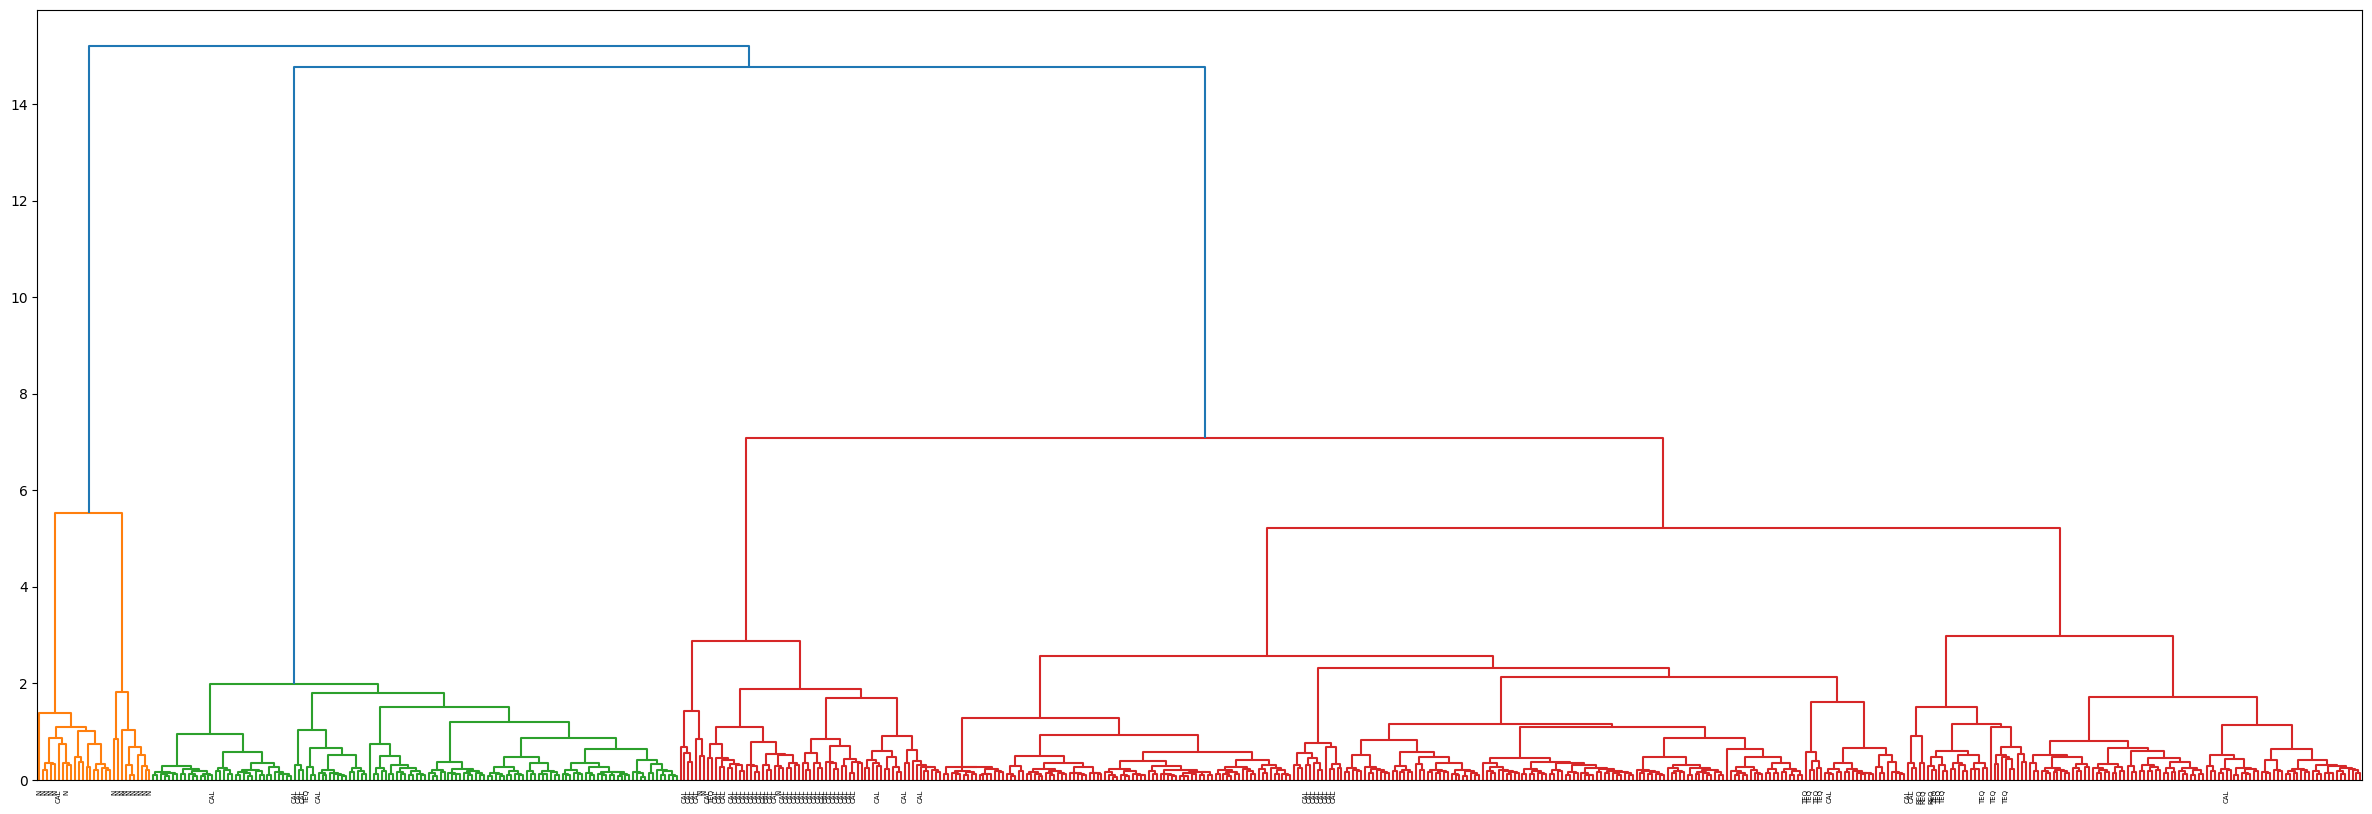

In [267]:
plt.figure(figsize=(30, 10))
Z = linkage(Xa, method="ward")
dendrogram(Z, labels=labs)
plt.show()

In [268]:
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)["labels"]

..cutHeight not given, setting it to 15.045089715288164  ===>  99% of the (truncated) height range in dendro.
..done.


In [269]:
clusters.max()

18

In [270]:
remaining_segments = remaining_segments.reset_index(drop=True)

In [280]:
cl = 10
cluster = remaining_segments[clusters == cl].copy().reset_index(drop=True)
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2023-08-25T12:39:10.000000Z,2023-08-25T12:47:30.000000Z,2023-08-25T12:41:40.000000Z,0.720424,0.453202,8,CAL
1,2022-08-16T12:32:30.000000Z,2022-08-16T12:41:40.000000Z,2022-08-16T12:35:00.000000Z,0.716862,0.413724,8,N
2,2022-08-15T22:40:54.845000Z,2022-08-15T22:55:54.845000Z,2022-08-15T22:43:24.845000Z,0.702885,0.416311,8,N
3,2022-08-21T20:27:30.000000Z,2022-08-21T20:30:00.000000Z,2022-08-21T20:27:30.000000Z,0.636041,0.389330,8,CAL
4,2022-12-19T04:51:40.000000Z,2022-12-19T04:54:10.000000Z,2022-12-19T04:51:40.000000Z,0.635567,0.500232,8,CAL
5,2023-05-20T16:05:42.320000Z,2023-05-20T16:07:22.320000Z,2023-05-20T16:05:42.320000Z,0.632052,NaN,15,CAL
6,2023-04-14T05:11:32.320000Z,2023-04-14T05:14:02.320000Z,2023-04-14T05:11:32.320000Z,0.630583,0.366571,8,CAL
7,2022-08-24T11:23:39.410000Z,2022-08-24T11:27:49.410000Z,2022-08-24T11:24:29.410000Z,0.627558,0.469693,8,CAL
8,2022-12-13T12:28:20.000000Z,2022-12-13T12:30:50.000000Z,2022-12-13T12:28:20.000000Z,0.622735,0.460989,8,CAL
9,2023-07-26T01:00:50.000000Z,2023-07-26T01:03:20.000000Z,2023-07-26T01:00:50.000000Z,0.618290,0.375725,8,CAL


In [234]:
labs = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["label"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[0]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)

In [ ]:
Xa = X.copy()
for i in range(Xa.shape[1]):
    x = np.delete(Xa[:, i], i)
    Xa[i, i] = np.min(x)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens)
lens = (lens == 1800).astype(float).reshape(-1, 1)

Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.hstack([Xa, np.isnan(Xa[:, -1]).astype(float).reshape(-1, 1)])
Xa = np.nan_to_num(Xa, nan=0.5)
a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

In [237]:
Z = linkage(Xa, method="ward")
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]
segments["cluster"] = clusters
segments["label"] = labs
segments.to_csv(f"../output/{network}/if/segments/{station}.csv")

..cutHeight not given, setting it to 30.10569914618996  ===>  99% of the (truncated) height range in dendro.
..done.


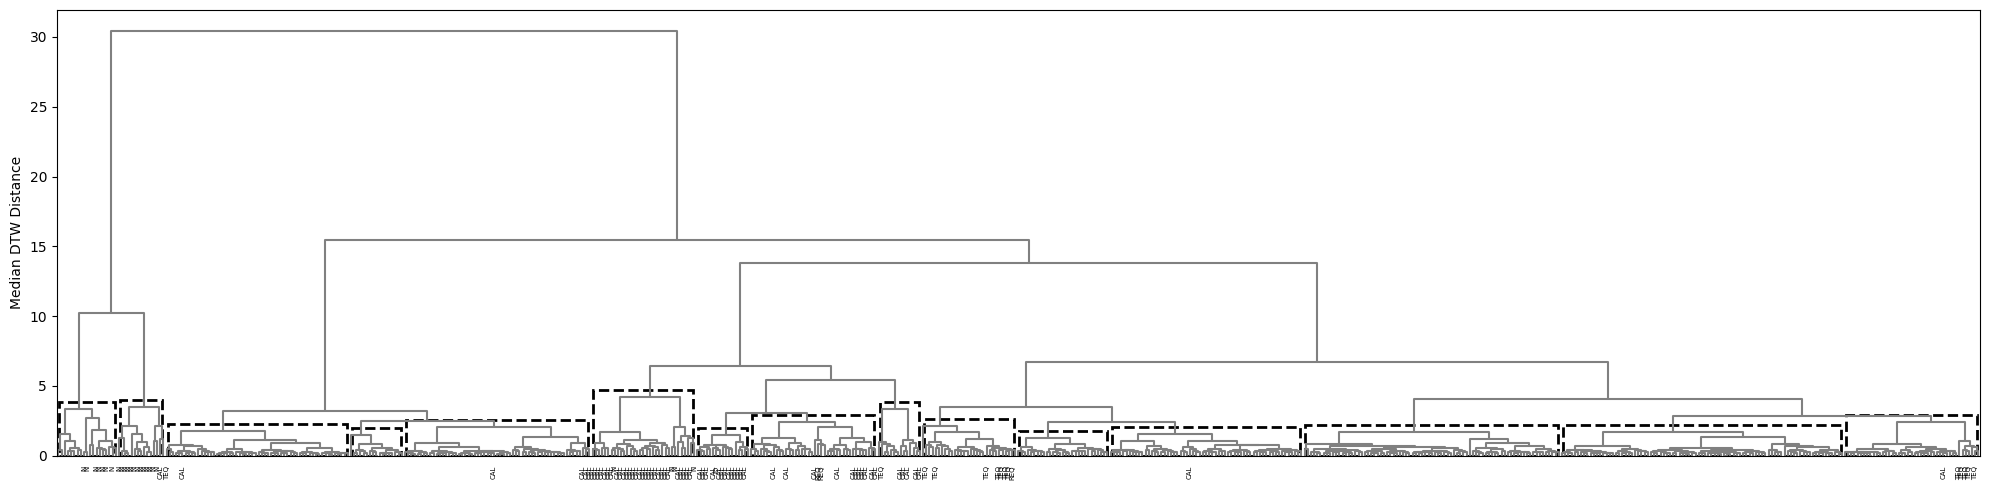

In [238]:
plt.figure(figsize=(20, 5))
# --- dendrogram ---
ddata = dendrogram(Z, labels=labs, link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 8  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/karat_dendrogram.pdf", dpi=300)
plt.show()

In [ ]:
clusters.max()

cl = 15
cluster = segments[clusters == cl].copy().reset_index(drop=True)
cluster

15

,start,stop,most_anomalous_start,scores,control_scores,cluster,label
0,2022-09-11T00:05:23.400000Z,2022-09-11T00:07:03.400000Z,2022-09-11T00:05:23.400000Z,0.671640,NaN,15,TEQ
1,2023-05-20T16:05:42.320000Z,2023-05-20T16:07:22.320000Z,2023-05-20T16:05:42.320000Z,0.632052,NaN,15,CAL
2,2023-05-01T06:29:52.320000Z,2023-05-01T06:31:32.320000Z,2023-05-01T06:29:52.320000Z,0.611004,NaN,15,CAL
3,2022-09-26T01:29:29.375000Z,2022-09-26T01:31:09.375000Z,2022-09-26T01:29:29.375000Z,0.610479,NaN,15,None
4,2022-09-22T09:09:37.390000Z,2022-09-22T09:11:17.390000Z,2022-09-22T09:09:37.390000Z,0.608948,NaN,15,CAL
5,2023-05-23T16:15:42.320000Z,2023-05-23T16:17:22.320000Z,2023-05-23T16:15:42.320000Z,0.605829,NaN,15,None
6,2022-09-26T03:35:29.375000Z,2022-09-26T03:37:09.375000Z,2022-09-26T03:35:29.375000Z,0.604144,NaN,15,None
7,2022-09-25T20:29:26.355000Z,2022-09-25T20:31:06.355000Z,2022-09-25T20:29:26.355000Z,0.603313,NaN,15,None
8,2023-02-19T13:25:47.055000Z,2023-02-19T13:27:27.055000Z,2023-02-19T13:25:47.055000Z,0.601963,NaN,15,None
9,2023-04-27T16:51:32.320000Z,2023-04-27T16:53:12.320000Z,2023-04-27T16:51:32.320000Z,0.601708,NaN,15,CAL


In [10]:
seg = cluster.iloc[0]
print(seg)
dt = str(seg["most_anomalous_start"])[:10]
t0 = obspy.UTCDateTime(seg["start"]) - timedelta(minutes=2)
t1 = obspy.UTCDateTime(seg["stop"]) + timedelta(minutes=2)
# t0 = obspy.UTCDateTime(seg["most_anomalous_start"]) #- timedelta(minutes=2)
# t1 = obspy.UTCDateTime(seg["most_anomalous_start"]) + timedelta(minutes=2)

start                   2022-06-03T10:01:34.625000Z
stop                    2022-06-03T10:05:44.625000Z
most_anomalous_start    2022-06-03T10:04:04.625000Z
scores                                     0.742787
control_scores                             0.366732
cluster                                          10
label                                             N
Name: 0, dtype: object


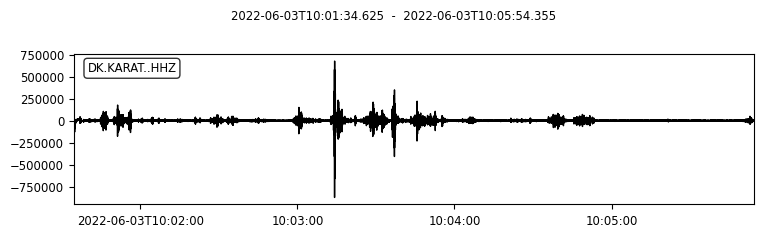

In [11]:
st = obspy.read(find_date_in_strings(paths, dt)[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

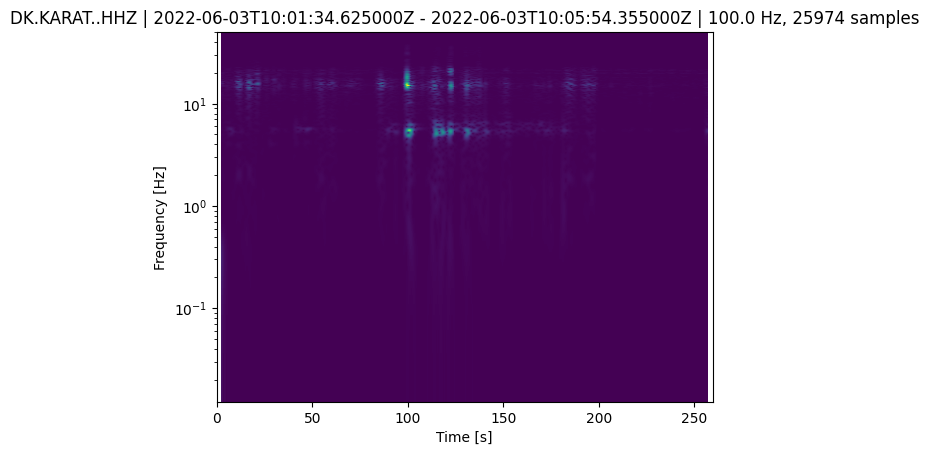

In [12]:
st[0].spectrogram(log=True, wlen=4, show=False)
plt.show()

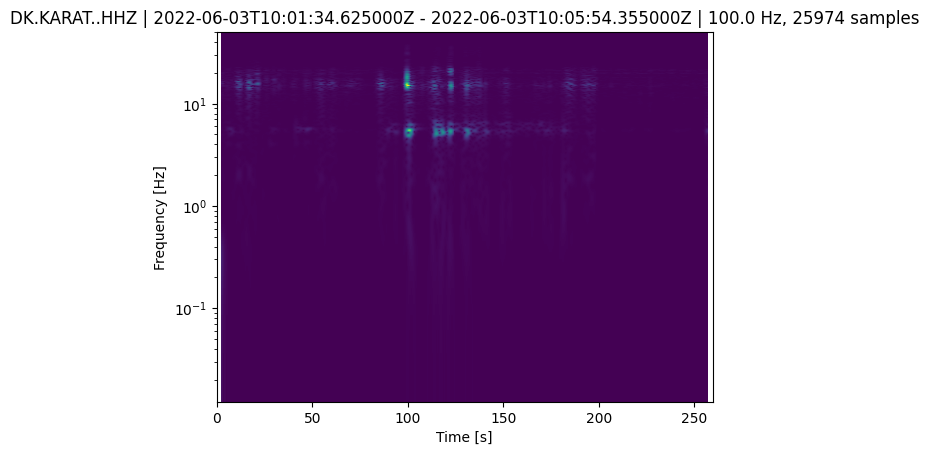

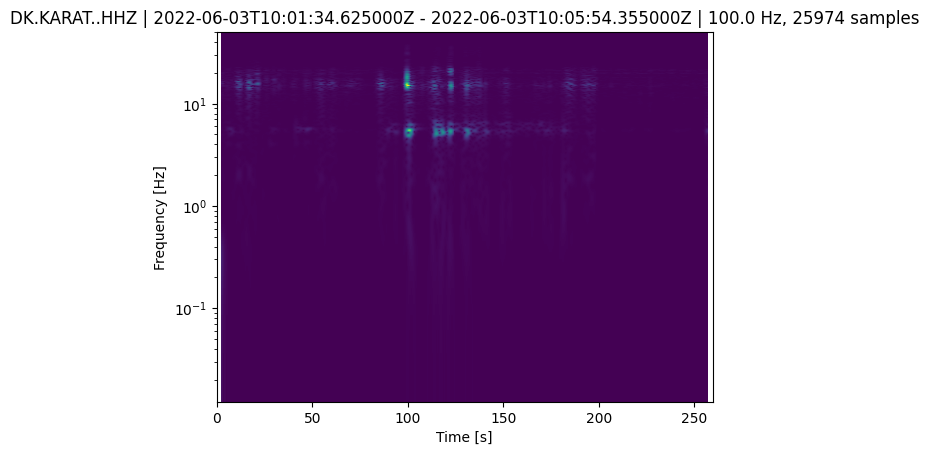

In [13]:
st[0].spectrogram(log=True, wlen=4, show=False)

### NUUG

In [249]:
station = "NUUG"
network = "DK"
nuug_paths = find_paths(network, station, "HHZ.D", start=2017, stop=2017)
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

In [250]:
dtw_path = f"../output/{network}/dtw/distances"

with open(f"{dtw_path}/{station}.pkl", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

In [251]:
Xa = X.copy()
for i in range(Xa.shape[1]):
    x = np.delete(Xa[:, i], i)
    Xa[i, i] = np.min(x)

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens).reshape(-1, 1)

Xa = np.hstack(
    [Xa, segments[["scores"]].values, lens, segments[["control_scores"]].values]
)
Xa = np.nan_to_num(Xa, nan=0.5)
a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

Z = linkage(Xa, method="ward")

In [252]:
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]

..cutHeight not given, setting it to 16.878350833069153  ===>  99% of the (truncated) height range in dendro.
..done.


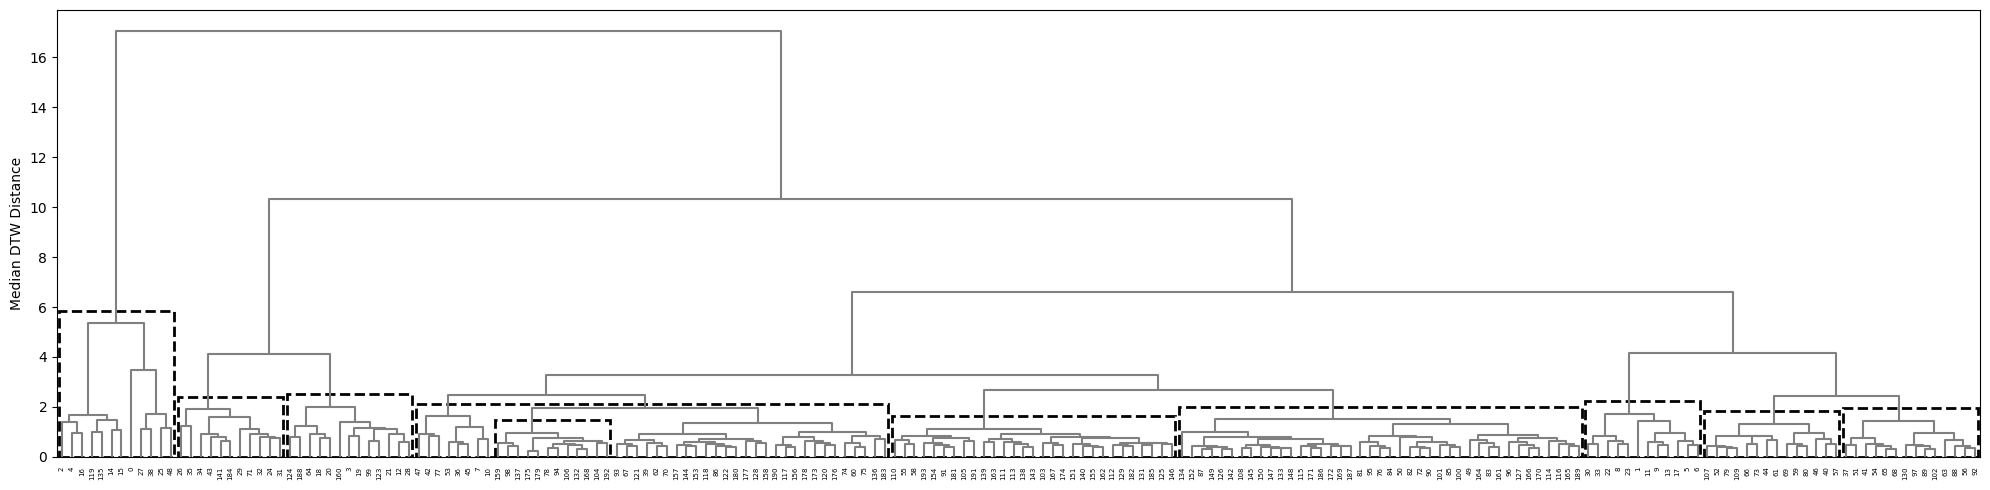

In [253]:
plt.figure(figsize=(20, 5))


# --- dendrogram ---
ddata = dendrogram(Z, link_color_func=lambda k: "grey")

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 2  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
plt.savefig("../plots/nuug_dendrogram.pdf", dpi=300)
plt.show()

In [254]:
cl = 9

cluster = segments[clusters == cl].copy().reset_index(drop=True)
# cluster["label"] = labs[clusters == cl]
cluster

,start,stop,most_anomalous_start,scores,control_scores,cluster
0,2017-06-17T23:39:11.680001Z,2017-06-18T00:17:31.680001Z,2017-06-17T23:40:01.680001Z,0.737263,0.711354,9
1,2017-03-10T10:01:41.680001Z,2017-03-10T10:05:51.680001Z,2017-03-10T10:02:31.680001Z,0.729234,0.377912,9
2,2017-01-29T02:11:41.680001Z,2017-01-29T02:19:11.680001Z,2017-01-29T02:12:31.680001Z,0.716197,0.459733,9
3,2017-05-26T23:07:31.680001Z,2017-05-26T23:10:51.680001Z,2017-05-26T23:08:21.680001Z,0.691934,0.428958,9
4,2017-05-31T23:55:51.680001Z,2017-05-31T23:58:21.680001Z,2017-05-31T23:55:51.680001Z,0.690715,0.369397,9
5,2017-01-29T14:25:51.680001Z,2017-01-29T14:33:21.680001Z,2017-01-29T14:27:31.680001Z,0.686385,0.490783,9
6,2017-01-24T09:45:51.680001Z,2017-01-24T09:49:11.680001Z,2017-01-24T09:46:41.680001Z,0.669697,0.456603,9
7,2017-01-23T15:09:11.680001Z,2017-01-23T15:12:31.680001Z,2017-01-23T15:10:01.680001Z,0.660183,0.420810,9
8,2017-01-23T15:05:51.680001Z,2017-01-23T15:08:21.680001Z,2017-01-23T15:06:41.680001Z,0.649989,0.419752,9
9,2017-01-24T09:43:21.680001Z,2017-01-24T09:45:01.680001Z,2017-01-24T09:43:21.680001Z,0.641872,NaN,9


In [20]:
seg = cluster.iloc[11]
print(seg)
dt = str(seg["most_anomalous_start"])[:10]
t0 = obspy.UTCDateTime(seg["start"]) - timedelta(minutes=2)
t1 = obspy.UTCDateTime(seg["stop"]) + timedelta(minutes=2)

start                   2017-03-22T00:05:51.680001Z
stop                    2017-03-22T00:07:31.680001Z
most_anomalous_start    2017-03-22T00:05:51.680001Z
scores                                     0.608622
control_scores                                  NaN
cluster                                           9
Name: 11, dtype: object


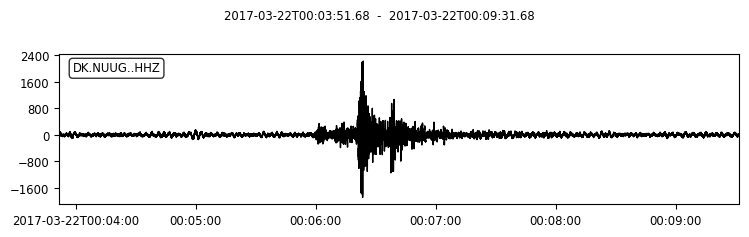

In [21]:
st = obspy.read(find_date_in_strings(nuug_paths, dt)[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

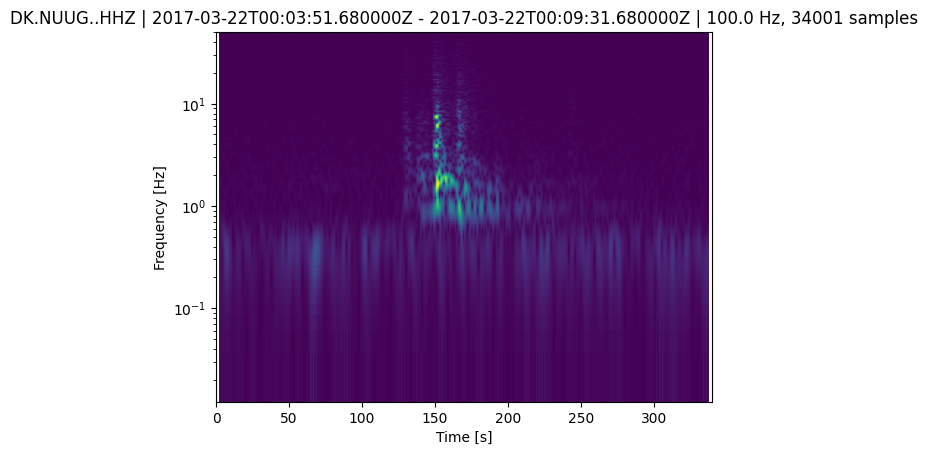

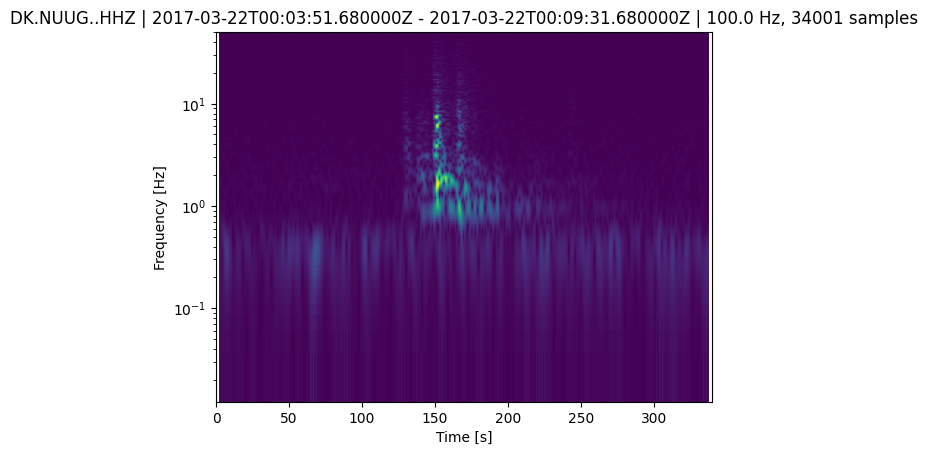

In [22]:
st[0].spectrogram(log=True, wlen=4, show=False)

In [23]:
segments["cluster"] = clusters

In [24]:
segments.to_csv(f"../output/{network}/if/segments/{station}.csv")

### ILL15

In [197]:
network = "XP"
station = "ILL15"
segments = pd.read_csv(f"../output/{network}/if/segments/{station}.csv", index_col=0)

In [198]:
dtw_path = f"../output/{network}/dtw/distances"

with open(f"{dtw_path}/{station}.pkl", "rb") as f:
    results = pickle.load(f)

X = np.zeros((len(results), len(results[0])))
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])

lens = []

for i in range(len(segments)):
    start = obspy.UTCDateTime(segments["start"][i])
    stop = obspy.UTCDateTime(segments["stop"][i])
    lens.append(min(stop - start, 1800))

lens = np.array(lens).reshape(-1, 1)

Xa = X.copy()

Xa = np.hstack([Xa, segments[["scores"]].values, lens])

a = np.nanmin(Xa, axis=0)
b = np.nanmax(Xa, axis=0)
Xa = (Xa - a) / (b - a)

Z = linkage(Xa, method="ward")

In [199]:
D = squareform(pdist(Xa, metric="euclidean"))
clusters = cutreeHybrid(Z, D, minClusterSize=10, deepSplit=3)
clusters = clusters["labels"]

..cutHeight not given, setting it to 36.744844133316356  ===>  99% of the (truncated) height range in dendro.
..done.


In [200]:
catalog = pd.read_csv("../catalogs/XP/flow_catalog.csv")
catalog = preproc_flow_annotations(catalog)

catalog = catalog[catalog["station"] == station].reset_index(drop=True)
catalog = catalog[catalog["confidence"] == "high"].reset_index(drop=True)

labs = []
for i in range(len(segments)):
    I, _, _ = iou(catalog, segments.iloc[[i]].reset_index(drop=True))
    try:
        labs.append(
            catalog["confidence"][np.where(np.append(I[0], np.diff(I)) > 0)[0]].values[
                0
            ]
        )
    except IndexError:
        labs.append(None)
labs = np.array(labs)
labs[labs == "high"] = "F"

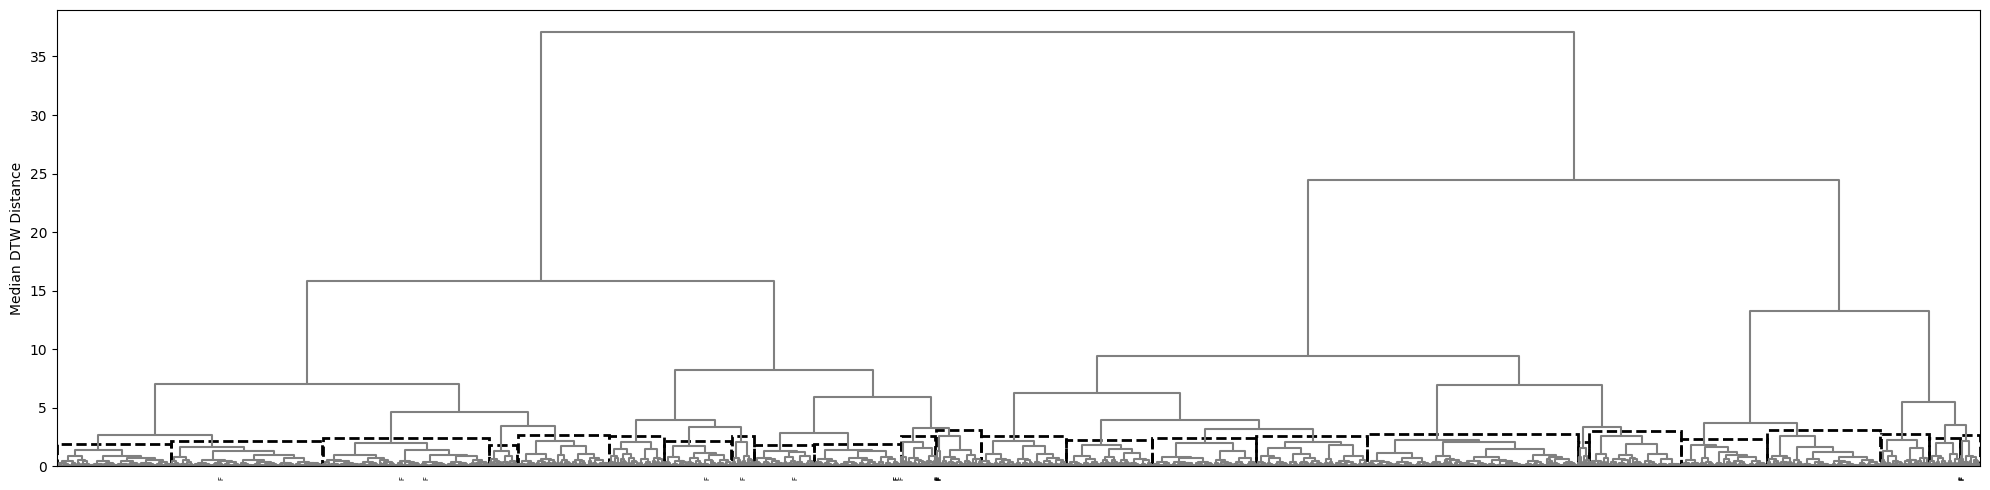

In [201]:
plt.figure(figsize=(20, 5))


# --- dendrogram ---
ddata = dendrogram(Z, link_color_func=lambda k: "grey", labels=labs)

leaf_order = ddata["leaves"]
clusters_ordered = clusters[leaf_order]

ax = plt.gca()

# x positions of leaves (scipy convention)
x_positions = np.arange(len(leaf_order)) * 10 + 5

# --- build tree structure to get correct heights ---
n = len(clusters)
node_members = {i: {i} for i in range(n)}
node_height = {i: 0 for i in range(n)}

for i, (c1, c2, dist, _) in enumerate(Z):
    c1, c2 = int(c1), int(c2)
    new_id = n + i

    members = node_members[c1] | node_members[c2]
    node_members[new_id] = members
    node_height[new_id] = dist

# --- compute height per cluster ---
cluster_heights = {}

for node_id, members in node_members.items():
    member_clusters = set(clusters[list(members)])

    if len(member_clusters) == 1:
        cid = next(iter(member_clusters))
        cluster_heights[cid] = max(cluster_heights.get(cid, 0), node_height[node_id])

# --- draw one box per cluster ---
gap = 2  # spacing so boxes don't touch

for cid in np.unique(clusters):
    idx = np.where(clusters_ordered == cid)[0]

    if len(idx) == 0:
        continue

    x0 = x_positions[idx.min()] - 5 + gap
    x1 = x_positions[idx.max()] + 5 - gap
    height = cluster_heights.get(cid, 0) + 0.5

    rect = plt.Rectangle(
        (x0, 0),
        x1 - x0,
        height,
        fill=False,
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
    ax.add_patch(rect)

plt.ylabel("Median DTW Distance")
plt.tight_layout()
# plt.savefig("../plots/nuug_dendrogram.pdf", dpi=300)
plt.show()

In [236]:
cl = 19
df = segments[clusters == cl].copy().reset_index(drop=True)
df["labels"] = labs[clusters == cl]
print(np.mean(df["labels"] == "F"))
df[df["labels"] == "F"]

0.01282051282051282


,start,stop,most_anomalous_start,scores,labels
14,2021-07-06T18:47:29.990000Z,2021-07-06T19:03:19.990000Z,2021-07-06T18:49:59.990000Z,0.683823,F


In [237]:
df.shape

(78, 5)

In [203]:
clusters.max()

24

In [196]:
df

,start,stop,most_anomalous_start,scores,labels
0,2022-06-01T11:15:12.650000Z,2022-06-01T11:25:12.650000Z,2022-06-01T11:21:02.650000Z,0.744285,None
1,2022-05-14T23:56:02.650000Z,2022-05-15T00:01:52.650000Z,2022-05-14T23:57:42.650000Z,0.741609,None
2,2020-09-01T00:01:34.070000Z,2020-09-01T00:06:34.070000Z,2020-09-01T00:03:14.070000Z,0.720797,None
3,2018-08-08T17:41:41.850003Z,2018-08-08T17:57:31.850003Z,2018-08-08T17:45:01.850003Z,0.718818,F
4,2022-05-14T15:27:42.650000Z,2022-05-14T15:32:42.650000Z,2022-05-14T15:28:32.650000Z,0.710851,None
...,...,...,...,...,...
105,2021-09-19T07:44:08.020000Z,2021-09-19T07:48:18.020000Z,2021-09-19T07:44:08.020000Z,0.593165,None
106,2022-06-08T12:37:42.650000Z,2022-06-08T12:53:32.650000Z,2022-06-08T12:45:12.650000Z,0.592896,None
107,2021-06-08T20:56:38.020000Z,2021-06-08T20:58:18.020000Z,2021-06-08T20:56:38.020000Z,0.589628,None
108,2022-06-22T21:32:42.650000Z,2022-06-22T21:47:42.650000Z,2022-06-22T21:36:02.650000Z,0.583549,None
